# Milestone 9 — Device Observed vs True Physiology

Analyzes how the Milestone 8 device/fault layer perturbs *true* physiology
into *observed* bedside telemetry for the 6-hour progressive-hypoxemia
scenario generated by `scripts/run_hypoxemia.py`.

Prerequisite — generate the data first:

```bash
uv run python scripts/run_hypoxemia.py
```

This writes two artifacts under `output/`:

* `progressive_hypoxemia.csv`          observed device telemetry (+ quality / status)
* `progressive_hypoxemia_truth.csv`    true physiological states (one per tick)

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

OUTPUT = Path("../output")

observed = pd.read_csv(
    OUTPUT / "progressive_hypoxemia.csv",
    parse_dates=["event_time"],
)
truth = pd.read_csv(
    OUTPUT / "progressive_hypoxemia_truth.csv",
    parse_dates=["event_time"],
)

print(f"observed: {observed.shape}  truth: {truth.shape}")
observed.head()

observed: (4303, 10)  truth: (4320, 8)


,event_time,sequence_number,heart_rate_bpm,spo2_pct,respiration_rate_bpm,temperature_c,systolic_bp_mmhg,diastolic_bp_mmhg,device_status,quality_code
0,2026-01-01T00:00:05.632024+00:00,1,72.0,98.0,14.0,36.8,120.0,76.0,CONNECTED,GOOD
1,2026-01-01T00:00:10.521791+00:00,2,72.0,98.0,14.0,36.8,120.0,76.0,CONNECTED,GOOD
2,2026-01-01T00:00:15.451341+00:00,3,72.0,98.0,14.0,36.8,121.0,76.0,CONNECTED,GOOD
3,2026-01-01T00:00:20.316592+00:00,4,71.0,98.0,14.0,36.8,120.0,76.0,CONNECTED,GOOD
4,2026-01-01T00:00:25.614936+00:00,5,73.0,98.0,14.0,36.8,121.0,76.0,CONNECTED,GOOD


## 1. Run overview

Two series of the same tick sequence; any missing observed tick is a device
dropout. Quality codes come from the bedside-monitor profile
(`default_bedside_monitor_config`).

In [2]:
dropout = len(truth) - len(observed)

print(f"true states:     {len(truth):>6}")
print(f"observed events: {len(observed):>6}")
print(f"dropout:         {dropout:>6}  ({dropout / len(truth):.2%})")
print(f"time span:       {truth['event_time'].min()} .. {truth['event_time'].max()}")
print(f"quality codes:   {observed['quality_code'].value_counts().sort_index().to_dict()}")

true states:       4320
observed events:   4303
dropout:             17  (0.39%)
time span:       2026-01-01 00:00:05+00:00 .. 2026-01-01 06:00:00+00:00
quality codes:   {'DEGRADED': 23, 'GOOD': 4280}


## 2. Observed vs true SpO2

The device rounds SpO2 to integer percentage points, so observed steps between
whole values while the true signal varies continuously; sporadic spikes appear
as `DEGRADED` samples and dropouts as missing ticks.

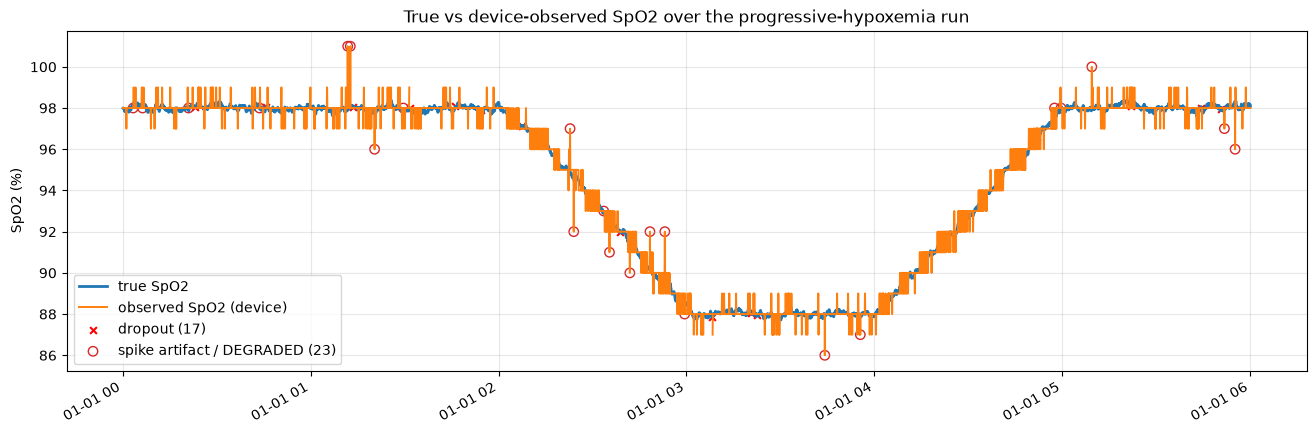

In [3]:
by_seq = truth.merge(
    observed,
    on="sequence_number",
    suffixes=("_truth", "_obs"),
    how="outer",
    indicator="present",
)

by_seq["event_time_obs"] = pd.to_datetime(by_seq["event_time_obs"], format="ISO8601")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    by_seq["event_time_truth"],
    by_seq["spo2_pct_truth"],
    label="true SpO2",
    color="#1f77b4",
    linewidth=2,
)
ax.plot(
    by_seq["event_time_truth"],
    by_seq["spo2_pct_obs"],
    label="observed SpO2 (device)",
    color="#ff7f0e",
    linewidth=1.4,
)

dropped = by_seq[by_seq["present"] == "left_only"]
ax.scatter(
    dropped["event_time_truth"],
    dropped["spo2_pct_truth"],
    marker="x",
    color="red",
    s=24,
    label=f"dropout ({len(dropped)})",
)

spikes = by_seq[by_seq["quality_code"] == "DEGRADED"]
ax.scatter(
    spikes["event_time_truth"],
    spikes["spo2_pct_obs"],
    marker="o",
    facecolors="none",
    edgecolors="#d62728",
    s=46,
    label=f"spike artifact / DEGRADED ({len(spikes)})",
)

ax.set_ylabel("SpO2 (%)")
ax.set_title("True vs device-observed SpO2 over the progressive-hypoxemia run")
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
fig.autofmt_xdate()
plt.show()

## 3. Deviation metrics

Pointwise `observed − true` per channel. Bias is the systematic offset, MAE/RMSE
the typical absolute deviation, and `max_abs` / `p95_abs` bound the tails
(largest spike artifacts).

In [4]:
channels = [
    "heart_rate_bpm",
    "spo2_pct",
    "respiration_rate_bpm",
    "temperature_c",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
]

rows = []
for channel in channels:
    diff = by_seq[f"{channel}_obs"] - by_seq[f"{channel}_truth"]
    rows.append(
        {
            "channel": channel,
            "n": int(diff.notna().sum()),
            "bias": diff.mean(),
            "mae": diff.abs().mean(),
            "rmse": (diff**2).mean() ** 0.5,
            "max_abs": diff.abs().max(),
            "p95_abs": diff.abs().quantile(0.95),
        }
    )

pd.DataFrame(rows).set_index("channel").round(3)

,n,bias,mae,rmse,max_abs,p95_abs
channel,,,,,,
heart_rate_bpm,4303,-0.003,0.412,0.545,4.979,1.010
spo2_pct,4303,-0.002,0.214,0.333,3.009,0.790
respiration_rate_bpm,4303,-0.003,0.274,0.341,1.164,0.670
temperature_c,4303,-0.002,0.030,0.036,0.114,0.066
systolic_bp_mmhg,4303,-0.003,0.458,0.573,2.029,1.119
diastolic_bp_mmhg,4303,-0.021,0.397,0.495,1.623,0.961


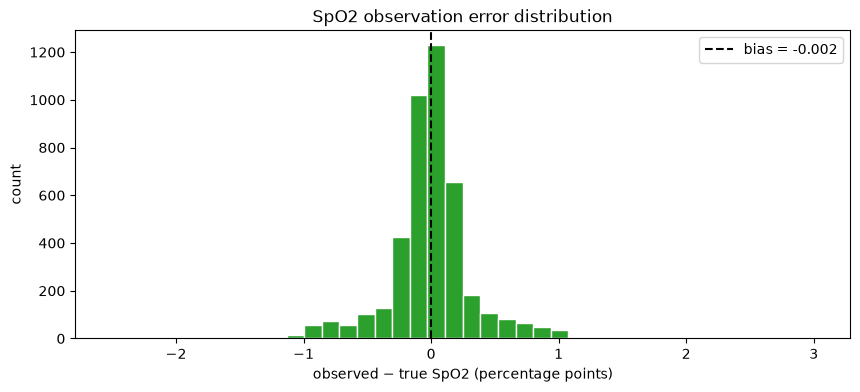

In [5]:
diff = by_seq["spo2_pct_obs"] - by_seq["spo2_pct_truth"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(diff.dropna(), bins=40, color="#2ca02c", edgecolor="white")
ax.axvline(
    diff.mean(),
    color="black",
    linestyle="--",
    label=f"bias = {diff.mean():.3f}",
)
ax.set_xlabel("observed − true SpO2 (percentage points)")
ax.set_ylabel("count")
ax.set_title("SpO2 observation error distribution")
ax.legend()
plt.show()

## 4. Sensor latency

The bedside-monitor profile applies a ~0.5 s mean sensor latency: every
`event_time` lands slightly after the true tick. Events are one-per-tick with a
monotonic sequence number, so latency is `event_time_obs − event_time_truth`.

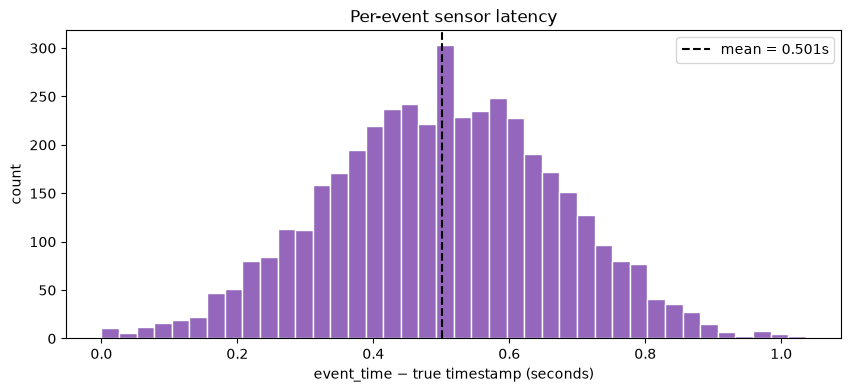

count    4303.000
mean        0.501
std         0.170
min         0.000
25%         0.385
50%         0.505
75%         0.619
max         1.036
dtype: float64

In [6]:
latency = (
    (by_seq["event_time_obs"] - by_seq["event_time_truth"])
    .dt.total_seconds()
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(latency, bins=40, color="#9467bd", edgecolor="white")
ax.axvline(
    latency.mean(),
    color="black",
    linestyle="--",
    label=f"mean = {latency.mean():.3f}s",
)
ax.set_xlabel("event_time − true timestamp (seconds)")
ax.set_ylabel("count")
ax.set_title("Per-event sensor latency")
ax.legend()
plt.show()

latency.describe().round(3)

## 5. Fault windows (flatline + disconnect)

`default_bedside_monitor_config` keeps windows off so long demos stay readable.
To show the full fault vocabulary this section runs a short, fully in-memory
baseline (seeded, no infrastructure) that adds two windows to the default
profile: an SpO2 **flatline** at 30s–3m and a **disconnect** at 5m–6m30s.
Faults freeze readings: POOR/blue while flatlining, LOST/red while disconnected.

In [7]:
from datetime import UTC, datetime, timedelta
from uuid import UUID

from healthcare_timeseries_lab.analysis import (
    align_observed_to_truth,
    dropout_count,
    error_metrics,
    quality_counts,
)
from healthcare_timeseries_lab.device import (
    DeviceSimulationConfig,
    DisconnectWindow,
    FlatlineWindow,
    default_bedside_monitor_config,
)
from healthcare_timeseries_lab.patients.models import PatientProfile
from healthcare_timeseries_lab.simulation.runner import (
    BaselineSimulationConfig,
    run_baseline_simulation,
)

patient = PatientProfile(
    patient_id=UUID("11111111-1111-1111-1111-111111111111"),
    age=45,
    sex="female",
    baseline_heart_rate_bpm=72.0,
    baseline_spo2_pct=98.0,
    baseline_respiration_rate_bpm=14.0,
    baseline_temperature_c=36.8,
    baseline_systolic_bp_mmhg=120.0,
    baseline_diastolic_bp_mmhg=76.0,
    variability_factor=1.0,
)

default = default_bedside_monitor_config()
device = DeviceSimulationConfig(
    seed=default.seed,
    latency_seconds=default.latency_seconds,
    dropout_probability=default.dropout_probability,
    channels=default.channels,
    flatline_windows=(
        FlatlineWindow(
            channel="spo2_pct",
            start_offset=timedelta(seconds=30),
            end_offset=timedelta(minutes=3),
        ),
    ),
    disconnect_windows=(
        DisconnectWindow(
            start_offset=timedelta(minutes=5),
            end_offset=timedelta(minutes=6, seconds=30),
        ),
    ),
)

config = BaselineSimulationConfig(
    simulation_id=UUID("12345678-1234-1234-1234-123456789012"),
    device_id=UUID("22222222-2222-2222-2222-222222222222"),
    start_time=datetime(2026, 2, 1, tzinfo=UTC),
    duration=timedelta(minutes=8),
    step=timedelta(seconds=5),
    seed=7,
)

result = run_baseline_simulation(patient=patient, config=config, device=device)
samples = align_observed_to_truth(result.states, result.events)

print(f"states: {len(result.states)}  events: {len(result.events)}")
print(f"dropout: {dropout_count(samples)}")
print(f"quality: {quality_counts(samples)}")
print(f"SpO2 error metrics: {error_metrics(samples, 'spo2_pct')}")

states: 96  events: 95
dropout: 1
quality: {'GOOD': 47, 'POOR': 29, 'DEGRADED': 1, 'LOST': 18}
SpO2 error metrics: ErrorMetrics(n=95, missing=1, bias=0.27069233148027394, mae=0.43578472776562494, rmse=0.6527337387166046, max_abs_error=1.9626752472596678, p95_abs_error=1.1902366117531642)


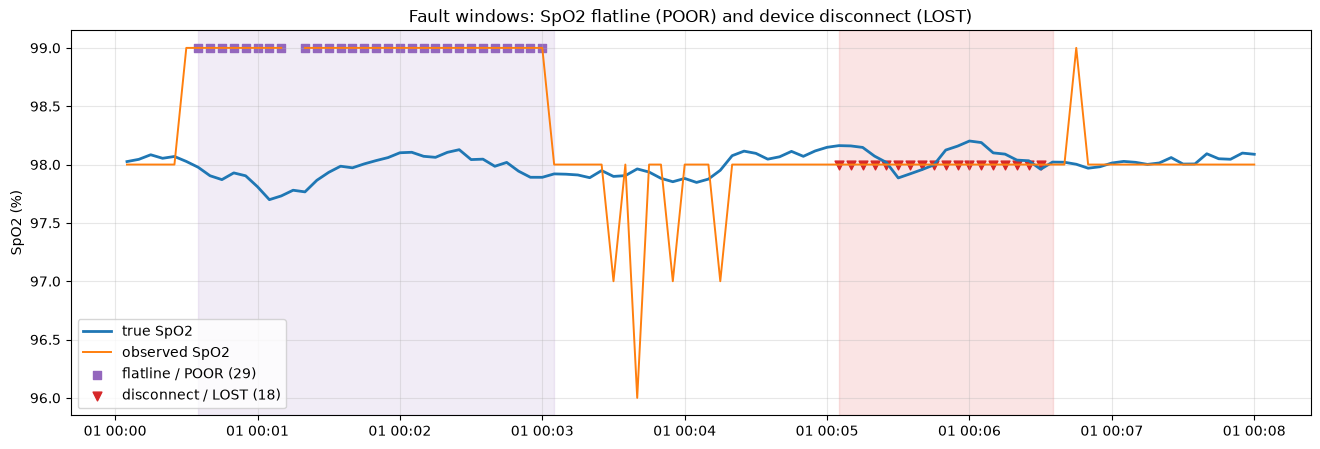

In [8]:
times = [sample.timestamp for sample in samples]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    times,
    [sample.true.spo2_pct for sample in samples],
    label="true SpO2",
    color="#1f77b4",
    linewidth=2,
)
ax.plot(
    times,
    [None if sample.event is None else sample.event.spo2_pct for sample in samples],
    label="observed SpO2",
    color="#ff7f0e",
    linewidth=1.4,
)

flat = [s for s in samples if s.event is not None and s.event.quality_code == "POOR"]
lost = [s for s in samples if s.event is not None and s.event.quality_code == "LOST"]

ax.scatter(
    [s.timestamp for s in flat],
    [s.event.spo2_pct for s in flat],
    marker="s",
    s=26,
    color="#9467bd",
    label=f"flatline / POOR ({len(flat)})",
)
ax.scatter(
    [s.timestamp for s in lost],
    [s.event.spo2_pct for s in lost],
    marker="v",
    s=40,
    color="#d62728",
    label=f"disconnect / LOST ({len(lost)})",
)
ax.axvspan(
    times[0] + timedelta(seconds=30),
    times[0] + timedelta(minutes=3),
    alpha=0.12,
    color="#9467bd",
)
ax.axvspan(
    times[0] + timedelta(minutes=5),
    times[0] + timedelta(minutes=6, seconds=30),
    alpha=0.12,
    color="#d62728",
)

ax.set_ylabel("SpO2 (%)")
ax.set_title("Fault windows: SpO2 flatline (POOR) and device disconnect (LOST)")
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.show()

## Summary

* Integer rounding dominates the SpO2 error: stays within roughly ±1 point,
  with a small tail from the occasional spike artifact (DEGRADED).
* Almost all events carry good quality; dropout removes only a fraction of
  samples and spikes a similarly small number, so the pipeline's downstream
  reads stay dense.
* Sensor latency is consistent with the configured ~0.5 s mean — every
  `event_time` trails its true tick, never the reverse.
* Fault windows freeze data at the last good reading: flatlines hold that value
  (POOR), disconnects hold pre-outage values (LOST); both are explicit in
  `quality_code`, so analytic queries can mark or discard them.